# Notebook 05: SHAP Explanations

This notebook generates SHAP explanations for the trained dry bean classification models.

### Cell 1: Imports and Configuration

In [5]:
from pathlib import Path
import json
import pickle
import random
import warnings
import sys
import subprocess

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

NOTEBOOK_NAME = "05_shap_explanations"

FORCE_RECOMPUTE_SHAP = False

N_SAMPLES_PER_GROUP = 3
MAX_TOTAL_SELECTED_SAMPLES = 40

SHAP_BACKGROUND_SIZE_TREE = 100
SHAP_BACKGROUND_SIZE_LINEAR = 100
SHAP_BACKGROUND_SIZE_MLP = 50

MLP_KERNEL_NSAMPLES = 100
TOP_K_LOCAL_FEATURES = 5


def find_project_root() -> Path:
    current_path = Path.cwd().resolve()

    if current_path.name == "notebooks":
        return current_path.parent

    if (current_path / "data").exists():
        return current_path

    for parent in current_path.parents:
        if (parent / "data").exists():
            return parent

    return current_path


PROJECT_ROOT = find_project_root()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results" / NOTEBOOK_NAME
PLOTS_DIR = PROJECT_ROOT / "plots" / NOTEBOOK_NAME
CONFIGS_DIR = PROJECT_ROOT / "configs"

TRAINING_RESULTS_DIR = PROJECT_ROOT / "results" / "03_model_training"
EVALUATION_RESULTS_DIR = PROJECT_ROOT / "results" / "04_model_evaluation"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Plots directory: {PLOTS_DIR}")

Project root: /home/iailab42/khans1/projects/xai
Results directory: /home/iailab42/khans1/projects/xai/results/05_shap_explanations
Plots directory: /home/iailab42/khans1/projects/xai/plots/05_shap_explanations


In [6]:
try:
    import shap
    print(f"SHAP already installed. Version: {shap.__version__}")
except ImportError:
    print("SHAP is not installed. Installing SHAP now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print(f"SHAP installed successfully. Version: {shap.__version__}")

SHAP is not installed. Installing SHAP now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 53.4 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 40.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]
SHAP installed successfully. Version: 0.52.0


### Cell 2:  Load Data, Models and Previous Results

In [7]:
def load_json(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing JSON file: {path}")

    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing CSV file: {path}")

    return pd.read_csv(path)


def load_model(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing model file: {path}")

    return joblib.load(path)


def save_pickle(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "wb") as file:
        pickle.dump(obj, file)


def load_pickle(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing pickle file: {path}")

    with open(path, "rb") as file:
        return pickle.load(file)


def save_json(data: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4)

In [14]:
feature_columns_raw = load_json(DATA_PROCESSED_DIR / "feature_columns.json")

if isinstance(feature_columns_raw, dict) and "feature_columns" in feature_columns_raw:
    feature_columns = feature_columns_raw["feature_columns"]
elif isinstance(feature_columns_raw, list):
    feature_columns = feature_columns_raw
else:
    raise ValueError(
        "feature_columns.json must be either a list or a dictionary with key 'feature_columns'."
    )

print(f"Number of feature columns: {len(feature_columns)}")
print(feature_columns)
label_mapping_raw = load_json(DATA_PROCESSED_DIR / "label_mapping.json")

X_train = load_csv(DATA_PROCESSED_DIR / "X_train.csv")
X_test = load_csv(DATA_PROCESSED_DIR / "X_test.csv")

X_train_scaled = load_csv(DATA_PROCESSED_DIR / "X_train_scaled.csv")
X_test_scaled = load_csv(DATA_PROCESSED_DIR / "X_test_scaled.csv")

y_train_full = load_csv(DATA_PROCESSED_DIR / "y_train.csv")
y_test_full = load_csv(DATA_PROCESSED_DIR / "y_test.csv")

TARGET_COLUMN = "Class_encoded"

y_train = y_train_full[TARGET_COLUMN].reset_index(drop=True)
y_test = y_test_full[TARGET_COLUMN].reset_index(drop=True)

train_sample_ids = y_train_full["sample_id"].reset_index(drop=True)
test_sample_ids = y_test_full["sample_id"].reset_index(drop=True)

CLASS_ID_TO_NAME = {
    0: "BARBUNYA",
    1: "BOMBAY",
    2: "CALI",
    3: "DERMASON",
    4: "HOROZ",
    5: "SEKER",
    6: "SIRA"
}

CLASS_NAME_TO_ID = {
    class_name: class_id
    for class_id, class_name in CLASS_ID_TO_NAME.items()
}

print("Data loaded successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Number of feature columns: 16
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']
Data loaded successfully.
X_train shape: (10834, 16)
X_test shape: (2709, 16)
X_train_scaled shape: (10834, 16)
X_test_scaled shape: (2709, 16)
y_train shape: (10834,)
y_test shape: (2709,)


In [9]:
models = {
    "logistic_regression": {
        "display_name": "Logistic Regression",
        "model": load_model(MODELS_DIR / "logistic_regression.pkl"),
        "uses_scaled_data": True,
        "explainer_type": "linear"
    },

    "decision_tree": {
        "display_name": "Decision Tree",
        "model": load_model(MODELS_DIR / "decision_tree.pkl"),
        "uses_scaled_data": False,
        "explainer_type": "tree"
    },

    "random_forest": {
        "display_name": "Random Forest",
        "model": load_model(MODELS_DIR / "random_forest.pkl"),
        "uses_scaled_data": False,
        "explainer_type": "tree"
    },

    "mlp": {
        "display_name": "MLP",
        "model": load_model(MODELS_DIR / "mlp.pkl"),
        "uses_scaled_data": True,
        "explainer_type": "kernel"
    }
}

print("All models loaded successfully.")

for model_name, model_info in models.items():
    input_type = "scaled" if model_info["uses_scaled_data"] else "unscaled"
    print(f"{model_info['display_name']}: uses {input_type} data")

All models loaded successfully.
Logistic Regression: uses scaled data
Decision Tree: uses unscaled data
Random Forest: uses unscaled data
MLP: uses scaled data


### Cell 3: Load Prediction Files, Evaluation files

In [10]:
prediction_data = {}

for model_name in models.keys():
    prediction_path = TRAINING_RESULTS_DIR / f"{model_name}_predictions.csv"
    prediction_data[model_name] = load_csv(prediction_path)

    print(f"{model_name}: {prediction_data[model_name].shape}")

print("All prediction files loaded successfully.")

logistic_regression: (2709, 3)
decision_tree: (2709, 3)
random_forest: (2709, 3)
mlp: (2709, 3)
All prediction files loaded successfully.


In [11]:
evaluation_metrics = load_csv(EVALUATION_RESULTS_DIR / "evaluation_metrics.csv")
classwise_performance = load_csv(EVALUATION_RESULTS_DIR / "classwise_performance.csv")
top_confusion_pairs = load_csv(EVALUATION_RESULTS_DIR / "top_confusion_pairs.csv")

print("Evaluation files loaded successfully.")

display(evaluation_metrics)
display(top_confusion_pairs.head(10))

Evaluation files loaded successfully.


,model_name,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,mlp,0.925065,0.935855,0.934572,0.935130,0.925053
1,logistic_regression,0.919158,0.930725,0.930049,0.930237,0.919290
2,random_forest,0.919158,0.931380,0.928934,0.930081,0.919102
3,decision_tree,0.895533,0.909421,0.910429,0.909784,0.895289


,model_name,true_class_id,true_class_name,predicted_class_id,predicted_class_name,confusion_count
0,decision_tree,6,SIRA,3,DERMASON,61
1,decision_tree,3,DERMASON,6,SIRA,57
2,random_forest,6,SIRA,3,DERMASON,55
3,logistic_regression,3,DERMASON,6,SIRA,53
4,mlp,6,SIRA,3,DERMASON,45
5,mlp,3,DERMASON,6,SIRA,44
6,random_forest,3,DERMASON,6,SIRA,43
7,logistic_regression,6,SIRA,3,DERMASON,41
8,decision_tree,6,SIRA,5,SEKER,22
9,random_forest,0,BARBUNYA,2,CALI,18


In [15]:
def validate_feature_columns(
    dataframe: pd.DataFrame,
    dataframe_name: str,
    expected_columns: list
):
    actual_columns = list(dataframe.columns)

    if actual_columns != expected_columns:
        missing_columns = set(expected_columns).difference(actual_columns)
        extra_columns = set(actual_columns).difference(expected_columns)

        print(f"\nColumn validation failed for: {dataframe_name}")
        print(f"Expected number of columns: {len(expected_columns)}")
        print(f"Actual number of columns: {len(actual_columns)}")
        print(f"Missing columns: {missing_columns}")
        print(f"Extra columns: {extra_columns}")

        print("\nExpected columns:")
        print(expected_columns)

        print("\nActual columns:")
        print(actual_columns)

        raise ValueError(f"{dataframe_name} columns do not match feature_columns.json")

    print(f"{dataframe_name}: column validation passed.")


def validate_prediction_file(
    model_name: str,
    prediction_df: pd.DataFrame,
    expected_rows: int
):
    required_columns = {
        "sample_id",
        "true_label",
        "predicted_label"
    }

    missing_columns = required_columns.difference(prediction_df.columns)

    if missing_columns:
        print(f"\nPrediction validation failed for: {model_name}")
        print(f"Missing columns: {missing_columns}")
        print(f"Available columns: {list(prediction_df.columns)}")

        raise ValueError(
            f"{model_name} prediction file is missing columns: {missing_columns}"
        )

    if len(prediction_df) != expected_rows:
        print(f"\nPrediction row count validation failed for: {model_name}")
        print(f"Expected rows: {expected_rows}")
        print(f"Actual rows: {len(prediction_df)}")

        raise ValueError(
            f"{model_name} prediction file has {len(prediction_df)} rows, "
            f"but expected {expected_rows} rows."
        )

    print(f"{model_name}: prediction validation passed.")


validate_feature_columns(
    dataframe=X_train,
    dataframe_name="X_train",
    expected_columns=feature_columns
)

validate_feature_columns(
    dataframe=X_test,
    dataframe_name="X_test",
    expected_columns=feature_columns
)

validate_feature_columns(
    dataframe=X_train_scaled,
    dataframe_name="X_train_scaled",
    expected_columns=feature_columns
)

validate_feature_columns(
    dataframe=X_test_scaled,
    dataframe_name="X_test_scaled",
    expected_columns=feature_columns
)

for model_name, prediction_df in prediction_data.items():
    validate_prediction_file(
        model_name=model_name,
        prediction_df=prediction_df,
        expected_rows=len(X_test)
    )

print("\nAll validation checks passed.")

X_train: column validation passed.
X_test: column validation passed.
X_train_scaled: column validation passed.
X_test_scaled: column validation passed.
logistic_regression: prediction validation passed.
decision_tree: prediction validation passed.
random_forest: prediction validation passed.
mlp: prediction validation passed.

All validation checks passed.


### Cell 4: Test Reference Table

In [16]:
test_reference = pd.DataFrame({
    "row_index": np.arange(len(X_test)),
    "sample_id": test_sample_ids,
    "true_label": y_test
})

test_reference["true_class_name"] = test_reference["true_label"].map(CLASS_ID_TO_NAME)

print("Test reference table created.")
display(test_reference.head())

Test reference table created.


,row_index,sample_id,true_label,true_class_name
0,0,1223,5,SEKER
1,1,11769,3,DERMASON
2,2,12059,3,DERMASON
3,3,7126,4,HOROZ
4,4,638,5,SEKER


### Cell 5: Samples from Models

In [17]:
def select_correct_samples(
    prediction_df: pd.DataFrame,
    model_name: str,
    class_id: int,
    group_name: str,
    n_samples: int,
    random_state: int = RANDOM_STATE
) -> pd.DataFrame:
    group_df = prediction_df[
        (prediction_df["true_label"] == class_id)
        & (prediction_df["predicted_label"] == class_id)
    ].copy()

    if len(group_df) == 0:
        return pd.DataFrame()

    selected_df = group_df.sample(
        n=min(n_samples, len(group_df)),
        random_state=random_state
    )

    selected_df["selected_from_model"] = model_name
    selected_df["selection_group"] = group_name

    return selected_df


def select_misclassified_samples(
    prediction_df: pd.DataFrame,
    model_name: str,
    true_class_id: int,
    predicted_class_id: int,
    group_name: str,
    n_samples: int,
    random_state: int = RANDOM_STATE
) -> pd.DataFrame:
    group_df = prediction_df[
        (prediction_df["true_label"] == true_class_id)
        & (prediction_df["predicted_label"] == predicted_class_id)
    ].copy()

    if len(group_df) == 0:
        return pd.DataFrame()

    selected_df = group_df.sample(
        n=min(n_samples, len(group_df)),
        random_state=random_state
    )

    selected_df["selected_from_model"] = model_name
    selected_df["selection_group"] = group_name

    return selected_df


selected_sample_groups = []

for model_name, prediction_df in prediction_data.items():

    selected_sample_groups.append(
        select_correct_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            class_id=CLASS_NAME_TO_ID["DERMASON"],
            group_name="correct_dermason",
            n_samples=N_SAMPLES_PER_GROUP
        )
    )

    selected_sample_groups.append(
        select_correct_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            class_id=CLASS_NAME_TO_ID["SIRA"],
            group_name="correct_sira",
            n_samples=N_SAMPLES_PER_GROUP
        )
    )

    selected_sample_groups.append(
        select_misclassified_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            true_class_id=CLASS_NAME_TO_ID["DERMASON"],
            predicted_class_id=CLASS_NAME_TO_ID["SIRA"],
            group_name="dermason_predicted_as_sira",
            n_samples=N_SAMPLES_PER_GROUP
        )
    )

    selected_sample_groups.append(
        select_misclassified_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            true_class_id=CLASS_NAME_TO_ID["SIRA"],
            predicted_class_id=CLASS_NAME_TO_ID["DERMASON"],
            group_name="sira_predicted_as_dermason",
            n_samples=N_SAMPLES_PER_GROUP
        )
    )

    selected_sample_groups.append(
        select_correct_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            class_id=CLASS_NAME_TO_ID["BOMBAY"],
            group_name="correct_bombay",
            n_samples=N_SAMPLES_PER_GROUP
        )
    )

    selected_sample_groups.append(
        select_misclassified_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            true_class_id=CLASS_NAME_TO_ID["BARBUNYA"],
            predicted_class_id=CLASS_NAME_TO_ID["CALI"],
            group_name="barbunya_predicted_as_cali",
            n_samples=N_SAMPLES_PER_GROUP
        )
    )


selected_sample_groups = [
    group_df for group_df in selected_sample_groups
    if not group_df.empty
]

selected_samples_raw = pd.concat(selected_sample_groups, ignore_index=True)

selected_samples = (
    selected_samples_raw
    .merge(test_reference[["row_index", "sample_id"]], on="sample_id", how="left")
    .drop_duplicates(subset=["sample_id"])
    .sort_values(by=["selection_group", "sample_id"])
    .reset_index(drop=True)
)

if len(selected_samples) > MAX_TOTAL_SELECTED_SAMPLES:
    selected_samples = (
        selected_samples
        .sample(n=MAX_TOTAL_SELECTED_SAMPLES, random_state=RANDOM_STATE)
        .sort_values(by=["selection_group", "sample_id"])
        .reset_index(drop=True)
    )

selected_samples["true_class_name"] = selected_samples["true_label"].map(CLASS_ID_TO_NAME)
selected_samples["predicted_class_name_in_source_model"] = selected_samples["predicted_label"].map(CLASS_ID_TO_NAME)

selected_samples = selected_samples[
    [
        "sample_id",
        "row_index",
        "selected_from_model",
        "selection_group",
        "true_label",
        "true_class_name",
        "predicted_label",
        "predicted_class_name_in_source_model"
    ]
]

selected_samples_path = RESULTS_DIR / "selected_samples.csv"
selected_samples.to_csv(selected_samples_path, index=False)

print(f"Selected samples saved to: {selected_samples_path}")
print(f"Number of selected unique samples: {len(selected_samples)}")

display(selected_samples)

Selected samples saved to: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/selected_samples.csv
Number of selected unique samples: 40


,sample_id,row_index,selected_from_model,selection_group,true_label,true_class_name,predicted_label,predicted_class_name_in_source_model
0,2573,192,decision_tree,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
1,2590,960,decision_tree,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
2,2591,66,logistic_regression,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
3,2790,126,logistic_regression,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
4,2883,553,mlp,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
5,3330,895,logistic_regression,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
6,3450,1567,logistic_regression,correct_bombay,1,BOMBAY,1,BOMBAY
7,3869,806,logistic_regression,correct_bombay,1,BOMBAY,1,BOMBAY
8,10554,1099,random_forest,correct_dermason,3,DERMASON,3,DERMASON
9,11193,2097,mlp,correct_dermason,3,DERMASON,3,DERMASON


### Cell 6: Model Input Data

In [18]:
selected_row_indices = selected_samples["row_index"].tolist()

X_explain_unscaled = X_test.iloc[selected_row_indices].reset_index(drop=True)
X_explain_scaled = X_test_scaled.iloc[selected_row_indices].reset_index(drop=True)

X_background_unscaled = X_train.sample(
    n=min(SHAP_BACKGROUND_SIZE_TREE, len(X_train)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

X_background_scaled_linear = X_train_scaled.sample(
    n=min(SHAP_BACKGROUND_SIZE_LINEAR, len(X_train_scaled)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

X_background_scaled_mlp = X_train_scaled.sample(
    n=min(SHAP_BACKGROUND_SIZE_MLP, len(X_train_scaled)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

model_input_data = {
    "logistic_regression": {
        "X_explain": X_explain_scaled,
        "X_background": X_background_scaled_linear,
        "input_type": "scaled"
    },

    "decision_tree": {
        "X_explain": X_explain_unscaled,
        "X_background": X_background_unscaled,
        "input_type": "unscaled"
    },

    "random_forest": {
        "X_explain": X_explain_unscaled,
        "X_background": X_background_unscaled,
        "input_type": "unscaled"
    },

    "mlp": {
        "X_explain": X_explain_scaled,
        "X_background": X_background_scaled_mlp,
        "input_type": "scaled"
    }
}

print("Model input data prepared.")

for model_name, data_info in model_input_data.items():
    print(
        f"{model_name}: explain shape = {data_info['X_explain'].shape}, "
        f"background shape = {data_info['X_background'].shape}, "
        f"input type = {data_info['input_type']}"
    )

Model input data prepared.
logistic_regression: explain shape = (40, 16), background shape = (100, 16), input type = scaled
decision_tree: explain shape = (40, 16), background shape = (100, 16), input type = unscaled
random_forest: explain shape = (40, 16), background shape = (100, 16), input type = unscaled
mlp: explain shape = (40, 16), background shape = (50, 16), input type = scaled


### Cell 7: SHAP utility functions

In [19]:
def normalize_shap_values(shap_output) -> np.ndarray:
    if hasattr(shap_output, "values"):
        values = shap_output.values
    else:
        values = shap_output

    if isinstance(values, list):
        values = np.stack(values, axis=2)

    values = np.asarray(values)

    if values.ndim == 2:
        values = values[:, :, np.newaxis]

    if values.ndim != 3:
        raise ValueError(
            f"Expected SHAP values with 3 dimensions, got shape {values.shape}"
        )

    return values


def compute_tree_shap_values(model, X_explain: pd.DataFrame):
    explainer = shap.TreeExplainer(model)

    try:
        shap_output = explainer(X_explain, check_additivity=False)
    except Exception:
        shap_output = explainer.shap_values(X_explain, check_additivity=False)

    shap_values = normalize_shap_values(shap_output)

    return explainer, shap_values


def compute_linear_shap_values(model, X_background: pd.DataFrame, X_explain: pd.DataFrame):
    try:
        explainer = shap.LinearExplainer(model, X_background)
        shap_output = explainer(X_explain)
    except Exception:
        explainer = shap.Explainer(model.predict_proba, X_background)
        shap_output = explainer(X_explain)

    shap_values = normalize_shap_values(shap_output)

    return explainer, shap_values


def compute_kernel_shap_values(
    model,
    X_background: pd.DataFrame,
    X_explain: pd.DataFrame,
    nsamples: int
):
    explainer = shap.KernelExplainer(model.predict_proba, X_background)

    shap_output = explainer.shap_values(
        X_explain,
        nsamples=nsamples
    )

    shap_values = normalize_shap_values(shap_output)

    return explainer, shap_values


def get_predicted_labels_for_selected_samples(model_name: str) -> np.ndarray:
    prediction_df = prediction_data[model_name]

    selected_predictions = selected_samples[["sample_id"]].merge(
        prediction_df[["sample_id", "predicted_label"]],
        on="sample_id",
        how="left"
    )

    if selected_predictions["predicted_label"].isna().any():
        raise ValueError(f"Missing selected sample predictions for {model_name}")

    return selected_predictions["predicted_label"].astype(int).to_numpy()

### Cell 8: SHAP computation

In [20]:
shap_results = {}

for model_name, model_info in models.items():

    shap_values_path = RESULTS_DIR / f"shap_values_{model_name}.pkl"

    if shap_values_path.exists() and not FORCE_RECOMPUTE_SHAP:
        print(f"Loading saved SHAP values for {model_name}")
        shap_result = load_pickle(shap_values_path)
        shap_results[model_name] = shap_result
        continue

    print(f"Computing SHAP values for {model_info['display_name']}")

    model = model_info["model"]
    explainer_type = model_info["explainer_type"]

    X_explain_model = model_input_data[model_name]["X_explain"]
    X_background_model = model_input_data[model_name]["X_background"]

    if explainer_type == "tree":
        explainer, shap_values = compute_tree_shap_values(
            model=model,
            X_explain=X_explain_model
        )

    elif explainer_type == "linear":
        explainer, shap_values = compute_linear_shap_values(
            model=model,
            X_background=X_background_model,
            X_explain=X_explain_model
        )

    elif explainer_type == "kernel":
        explainer, shap_values = compute_kernel_shap_values(
            model=model,
            X_background=X_background_model,
            X_explain=X_explain_model,
            nsamples=MLP_KERNEL_NSAMPLES
        )

    else:
        raise ValueError(f"Unknown explainer type: {explainer_type}")

    predicted_labels = get_predicted_labels_for_selected_samples(model_name)

    shap_result = {
        "model_name": model_name,
        "display_name": model_info["display_name"],
        "explainer_type": explainer_type,
        "input_type": model_input_data[model_name]["input_type"],
        "feature_columns": feature_columns,
        "selected_samples": selected_samples.copy(),
        "predicted_labels": predicted_labels,
        "shap_values": shap_values
    }

    save_pickle(shap_result, shap_values_path)
    shap_results[model_name] = shap_result

    print(f"Saved SHAP values: {shap_values_path}")
    print(f"SHAP values shape for {model_name}: {shap_values.shape}")

print("SHAP computation finished for all models.")

Computing SHAP values for Logistic Regression
Saved SHAP values: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/shap_values_logistic_regression.pkl
SHAP values shape for logistic_regression: (40, 16, 7)
Computing SHAP values for Decision Tree
Saved SHAP values: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/shap_values_decision_tree.pkl
SHAP values shape for decision_tree: (40, 16, 7)
Computing SHAP values for Random Forest
Saved SHAP values: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/shap_values_random_forest.pkl
SHAP values shape for random_forest: (40, 16, 7)
Computing SHAP values for MLP


  0%|          | 0/40 [00:00<?, ?it/s]

Saved SHAP values: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/shap_values_mlp.pkl
SHAP values shape for mlp: (40, 16, 7)
SHAP computation finished for all models.


### Cell 9: Global SHAP feature Importance

In [21]:
def calculate_global_shap_importance(
    model_name: str,
    shap_result: dict
) -> pd.DataFrame:
    shap_values = shap_result["shap_values"]

    mean_abs_shap_all_classes = np.mean(np.abs(shap_values), axis=(0, 2))

    importance_df = pd.DataFrame({
        "model_name": model_name,
        "display_name": shap_result["display_name"],
        "feature": feature_columns,
        "mean_abs_shap": mean_abs_shap_all_classes
    })

    importance_df = importance_df.sort_values(
        by="mean_abs_shap",
        ascending=False
    ).reset_index(drop=True)

    importance_df["rank"] = np.arange(1, len(importance_df) + 1)

    return importance_df


global_importance_tables = []

for model_name, shap_result in shap_results.items():
    importance_df = calculate_global_shap_importance(
        model_name=model_name,
        shap_result=shap_result
    )

    importance_path = RESULTS_DIR / f"shap_feature_importance_{model_name}.csv"
    importance_df.to_csv(importance_path, index=False)

    global_importance_tables.append(importance_df)

    print(f"Saved global SHAP importance: {importance_path}")

global_shap_importance = pd.concat(
    global_importance_tables,
    ignore_index=True
)

global_shap_importance_path = RESULTS_DIR / "shap_feature_importance_all_models.csv"
global_shap_importance.to_csv(global_shap_importance_path, index=False)

print(f"Saved combined SHAP importance: {global_shap_importance_path}")

display(global_shap_importance.head(20))

Saved global SHAP importance: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/shap_feature_importance_logistic_regression.csv
Saved global SHAP importance: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/shap_feature_importance_decision_tree.csv
Saved global SHAP importance: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/shap_feature_importance_random_forest.csv
Saved global SHAP importance: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/shap_feature_importance_mlp.csv
Saved combined SHAP importance: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/shap_feature_importance_all_models.csv


,model_name,display_name,feature,mean_abs_shap,rank
0,logistic_regression,Logistic Regression,ShapeFactor1,1.377006,1
1,logistic_regression,Logistic Regression,MinorAxisLength,1.035575,2
2,logistic_regression,Logistic Regression,EquivDiameter,0.852944,3
3,logistic_regression,Logistic Regression,Perimeter,0.851588,4
4,logistic_regression,Logistic Regression,ConvexArea,0.752849,5
5,logistic_regression,Logistic Regression,MajorAxisLength,0.747598,6
6,logistic_regression,Logistic Regression,Area,0.734999,7
7,logistic_regression,Logistic Regression,ShapeFactor2,0.659466,8
8,logistic_regression,Logistic Regression,ShapeFactor4,0.607852,9
9,logistic_regression,Logistic Regression,roundness,0.436859,10


### Cell 10: Local SHAP Explanation

In [22]:
def create_local_explanation_table(
    model_name: str,
    shap_result: dict,
    top_k: int = TOP_K_LOCAL_FEATURES
) -> pd.DataFrame:
    shap_values = shap_result["shap_values"]
    predicted_labels = shap_result["predicted_labels"]
    input_type = shap_result["input_type"]

    local_rows = []

    for sample_position in range(len(selected_samples)):
        selected_sample = selected_samples.iloc[sample_position]
        predicted_class_id = int(predicted_labels[sample_position])

        if shap_values.shape[2] == 1:
            class_shap_values = shap_values[sample_position, :, 0]
        else:
            class_shap_values = shap_values[sample_position, :, predicted_class_id]

        top_feature_indices = np.argsort(np.abs(class_shap_values))[::-1][:top_k]

        original_row = X_explain_unscaled.iloc[sample_position]
        model_input_row = model_input_data[model_name]["X_explain"].iloc[sample_position]

        for rank, feature_index in enumerate(top_feature_indices, start=1):
            feature_name = feature_columns[feature_index]

            local_rows.append({
                "model_name": model_name,
                "display_name": shap_result["display_name"],
                "input_type": input_type,
                "sample_id": selected_sample["sample_id"],
                "row_index": selected_sample["row_index"],
                "selection_group": selected_sample["selection_group"],
                "selected_from_model": selected_sample["selected_from_model"],
                "true_label": int(selected_sample["true_label"]),
                "true_class_name": selected_sample["true_class_name"],
                "explained_predicted_label": predicted_class_id,
                "explained_predicted_class_name": CLASS_ID_TO_NAME[predicted_class_id],
                "feature_rank": rank,
                "feature": feature_name,
                "shap_value": class_shap_values[feature_index],
                "abs_shap_value": abs(class_shap_values[feature_index]),
                "original_feature_value": original_row[feature_name],
                "model_input_feature_value": model_input_row[feature_name]
            })

    return pd.DataFrame(local_rows)


local_explanation_tables = []

for model_name, shap_result in shap_results.items():
    local_df = create_local_explanation_table(
        model_name=model_name,
        shap_result=shap_result,
        top_k=TOP_K_LOCAL_FEATURES
    )

    local_path = RESULTS_DIR / f"local_shap_explanations_{model_name}.csv"
    local_df.to_csv(local_path, index=False)

    local_explanation_tables.append(local_df)

    print(f"Saved local SHAP explanations: {local_path}")

local_shap_explanations = pd.concat(
    local_explanation_tables,
    ignore_index=True
)

local_all_path = RESULTS_DIR / "local_shap_explanations_all_models.csv"
local_shap_explanations.to_csv(local_all_path, index=False)

print(f"Saved combined local SHAP explanations: {local_all_path}")

display(local_shap_explanations.head(30))

Saved local SHAP explanations: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/local_shap_explanations_logistic_regression.csv
Saved local SHAP explanations: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/local_shap_explanations_decision_tree.csv
Saved local SHAP explanations: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/local_shap_explanations_random_forest.csv
Saved local SHAP explanations: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/local_shap_explanations_mlp.csv
Saved combined local SHAP explanations: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/local_shap_explanations_all_models.csv


,model_name,display_name,input_type,sample_id,row_index,selection_group,selected_from_model,true_label,true_class_name,explained_predicted_label,explained_predicted_class_name,feature_rank,feature,shap_value,abs_shap_value,original_feature_value,model_input_feature_value
0,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,ShapeFactor1,2.864523,2.864523,0.005315,-1.105093
1,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,roundness,0.864478,0.864478,0.904533,0.518322
2,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,MinorAxisLength,0.720907,0.720907,240.513029,0.847777
3,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,EquivDiameter,0.711784,0.711784,293.647535,0.686391
4,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,ShapeFactor2,0.638080,0.638080,0.001452,-0.449477
5,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,ShapeFactor1,1.908388,1.908388,0.005690,-0.773087
6,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,ShapeFactor2,1.424755,1.424755,0.001174,-0.916843
7,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,ShapeFactor4,-0.843588,0.843588,0.997570,0.573635
8,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,Eccentricity,0.807930,0.807930,0.814855,0.703244
9,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,MajorAxisLength,0.791775,0.791775,386.987870,0.783986


### Cell 11: GLobal SHAP bar chart plot

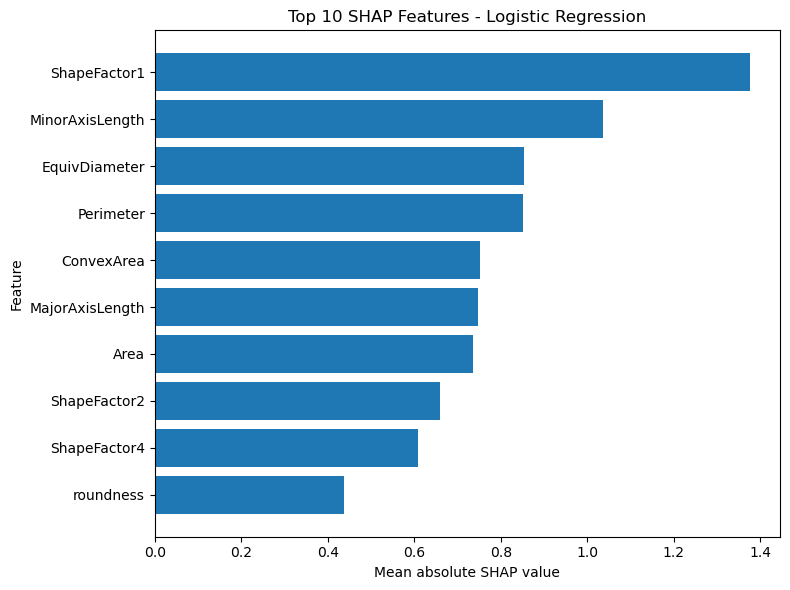

Saved plot: /home/iailab42/khans1/projects/xai/plots/05_shap_explanations/shap_bar_logistic_regression.png


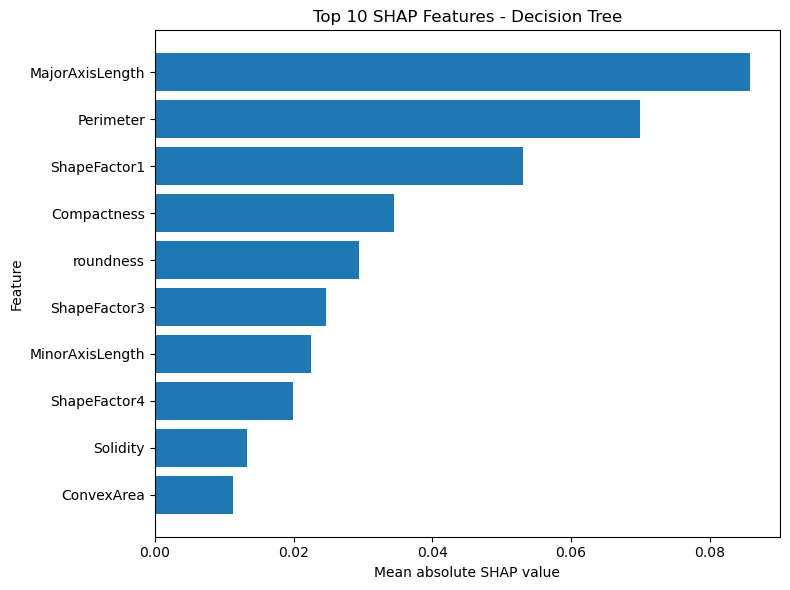

Saved plot: /home/iailab42/khans1/projects/xai/plots/05_shap_explanations/shap_bar_decision_tree.png


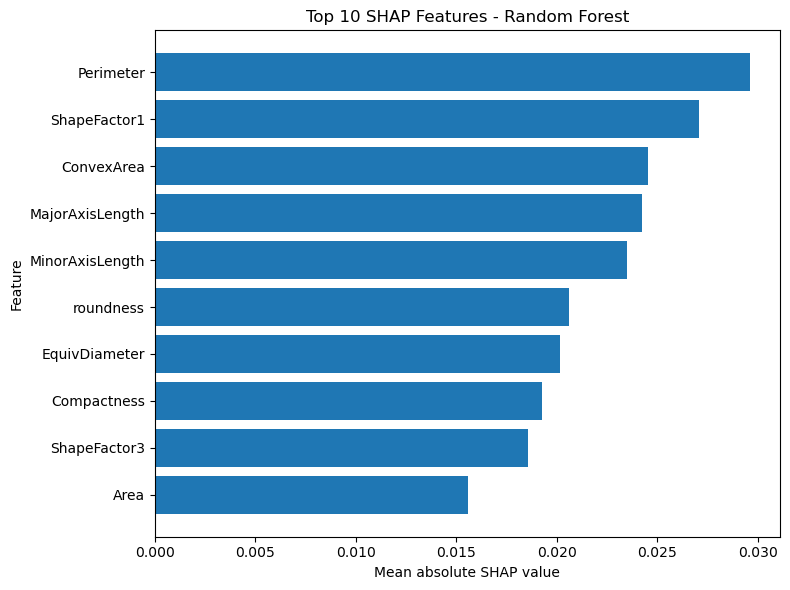

Saved plot: /home/iailab42/khans1/projects/xai/plots/05_shap_explanations/shap_bar_random_forest.png


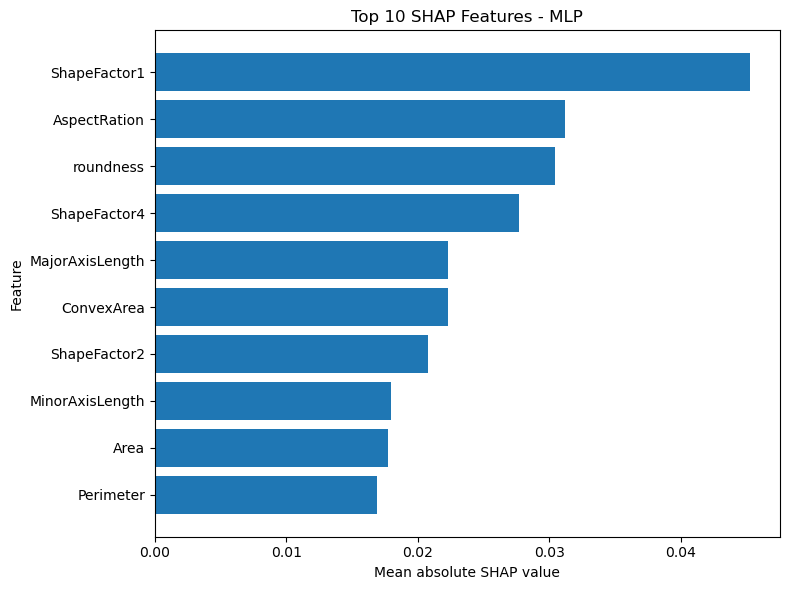

Saved plot: /home/iailab42/khans1/projects/xai/plots/05_shap_explanations/shap_bar_mlp.png


In [23]:
def plot_global_shap_bar(
    importance_df: pd.DataFrame,
    model_name: str,
    display_name: str,
    top_n: int = 10
):
    plot_df = importance_df.head(top_n).sort_values(
        by="mean_abs_shap",
        ascending=True
    )

    plt.figure(figsize=(8, 6))
    plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} SHAP Features - {display_name}")
    plt.tight_layout()

    plot_path = PLOTS_DIR / f"shap_bar_{model_name}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    return plot_path


for model_name, shap_result in shap_results.items():
    model_importance = global_shap_importance[
        global_shap_importance["model_name"] == model_name
    ]

    plot_path = plot_global_shap_bar(
        importance_df=model_importance,
        model_name=model_name,
        display_name=shap_result["display_name"],
        top_n=10
    )

    print(f"Saved plot: {plot_path}")

### Cell 12: Plot SHAP Summary plots for all models

/tmp/ipykernel_1266613/2665529039.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


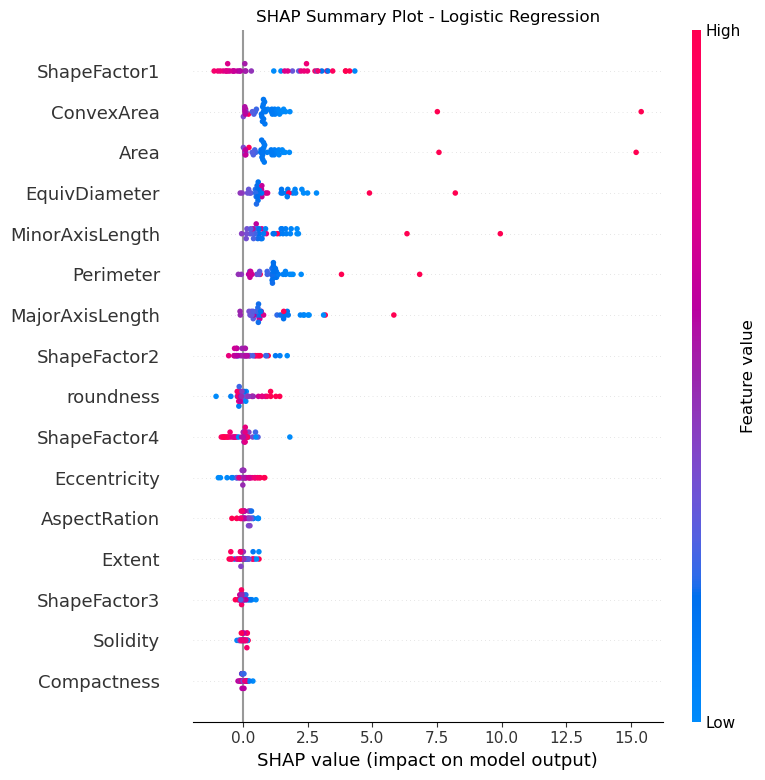

Saved SHAP summary plot: /home/iailab42/khans1/projects/xai/plots/05_shap_explanations/shap_summary_logistic_regression.png


/tmp/ipykernel_1266613/2665529039.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


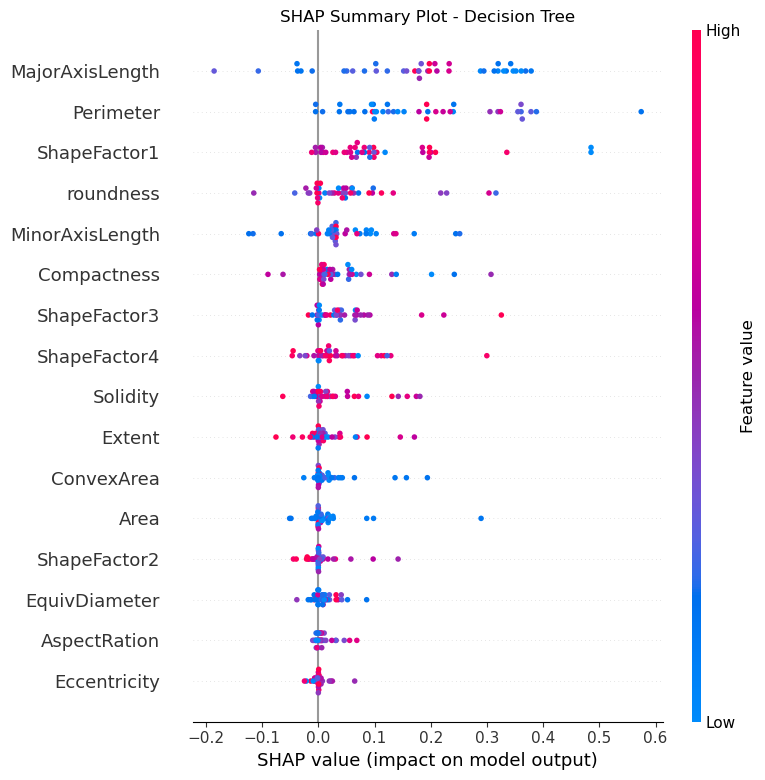

Saved SHAP summary plot: /home/iailab42/khans1/projects/xai/plots/05_shap_explanations/shap_summary_decision_tree.png


/tmp/ipykernel_1266613/2665529039.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


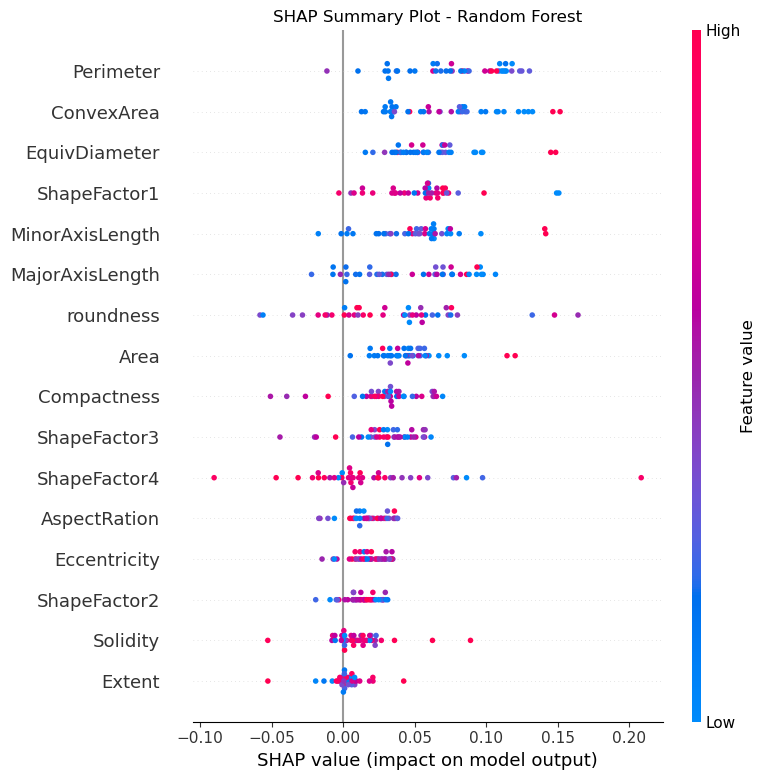

Saved SHAP summary plot: /home/iailab42/khans1/projects/xai/plots/05_shap_explanations/shap_summary_random_forest.png


/tmp/ipykernel_1266613/2665529039.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


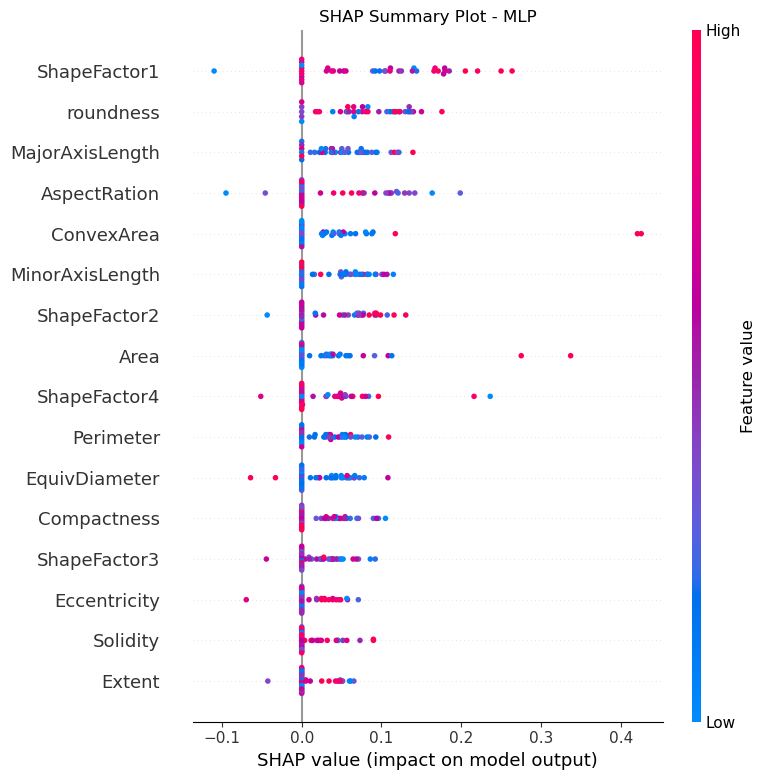

Saved SHAP summary plot: /home/iailab42/khans1/projects/xai/plots/05_shap_explanations/shap_summary_mlp.png


In [24]:
def plot_shap_summary_for_model(
    model_name: str,
    shap_result: dict
):
    shap_values = shap_result["shap_values"]
    predicted_labels = shap_result["predicted_labels"]
    X_explain_model = model_input_data[model_name]["X_explain"]

    class_specific_values = []

    for sample_position, predicted_class_id in enumerate(predicted_labels):
        if shap_values.shape[2] == 1:
            class_specific_values.append(shap_values[sample_position, :, 0])
        else:
            class_specific_values.append(shap_values[sample_position, :, int(predicted_class_id)])

    class_specific_values = np.array(class_specific_values)

    plt.figure()
    shap.summary_plot(
        class_specific_values,
        X_explain_model,
        feature_names=feature_columns,
        show=False
    )

    plt.title(f"SHAP Summary Plot - {shap_result['display_name']}")
    plt.tight_layout()

    plot_path = PLOTS_DIR / f"shap_summary_{model_name}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    return plot_path


for model_name, shap_result in shap_results.items():
    plot_path = plot_shap_summary_for_model(
        model_name=model_name,
        shap_result=shap_result
    )

    print(f"Saved SHAP summary plot: {plot_path}")

In [25]:
shap_summary = {
    "notebook": NOTEBOOK_NAME,
    "random_state": RANDOM_STATE,
    "force_recompute_shap": FORCE_RECOMPUTE_SHAP,
    "models_explained": list(models.keys()),
    "number_of_selected_samples": int(len(selected_samples)),
    "selected_samples_path": str(RESULTS_DIR / "selected_samples.csv"),
    "global_importance_path": str(RESULTS_DIR / "shap_feature_importance_all_models.csv"),
    "local_explanations_path": str(RESULTS_DIR / "local_shap_explanations_all_models.csv"),
    "background_sizes": {
        "tree": SHAP_BACKGROUND_SIZE_TREE,
        "linear": SHAP_BACKGROUND_SIZE_LINEAR,
        "mlp": SHAP_BACKGROUND_SIZE_MLP
    },
    "mlp_kernel_nsamples": MLP_KERNEL_NSAMPLES,
    "top_k_local_features": TOP_K_LOCAL_FEATURES,
    "model_input_types": {
        model_name: model_input_data[model_name]["input_type"]
        for model_name in models.keys()
    },
    "saved_outputs": {
        "selected_samples": "results/05_shap_explanations/selected_samples.csv",
        "shap_values_per_model": [
            f"results/05_shap_explanations/shap_values_{model_name}.pkl"
            for model_name in models.keys()
        ],
        "global_feature_importance_per_model": [
            f"results/05_shap_explanations/shap_feature_importance_{model_name}.csv"
            for model_name in models.keys()
        ],
        "combined_global_feature_importance": "results/05_shap_explanations/shap_feature_importance_all_models.csv",
        "local_explanations_per_model": [
            f"results/05_shap_explanations/local_shap_explanations_{model_name}.csv"
            for model_name in models.keys()
        ],
        "combined_local_explanations": "results/05_shap_explanations/local_shap_explanations_all_models.csv"
    }
}

summary_path = RESULTS_DIR / "shap_summary.json"
save_json(shap_summary, summary_path)

print(f"Saved SHAP summary: {summary_path}")

Saved SHAP summary: /home/iailab42/khans1/projects/xai/results/05_shap_explanations/shap_summary.json
